<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
         width="500"/>
</p>

<h2 align="left"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="left"><i>Alumno(a): Luis Carlos Alvarado</i></h2>

## 1. Introducción al problema

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

import statsmodels.api as sm
from sklearn.base import is_classifier, is_regressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, make_scorer, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score,  RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

from numpy.linalg import inv, LinAlgError
from scipy.stats import norm, loguniform
from joblib import dump, load

import time
import warnings
from sklearn.exceptions import FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)
warnings.simplefilter('ignore', UserWarning)

from funciones import dummify, dqr, drop_outliers_iqr, metrics, lr_coef_importance, confusion_matrix_mult, confusion_matrix_binary, build_strategy_to_majority, smote_fit_resample, svc_hiper_search_binary, svc_hiper_search_mult, compare_models_multi_data, train_cluster_then_classify

In [2]:
data = pd.read_excel('BD_factores_de_riesgo.xlsx')
data

,Apellidos y Nombre(s),Edad,Sexo,Peso al Nacer,Horas de sueño,Duerme menos de 8 horas,Familiares con obesidad,Codificación Familiares con obesidad,Familiares con DM,Codificación Familiares con DM,...,Sistólica en mmHg,Diastólica en mmHg,HTA Niñas,HTA niños,HTA adolescentes,HTA adultos,Clasificación HTA,Casual Glucemia mg/dl,Alteración,Diabetes
0,TORRES AVILA CAMILA YOLETH,6,1,2,8.0,0,1,1,1,1,...,100,70,0.0,NaN,NaN,NaN,0,112,1,0
1,VALDEZ CHAIREZ CONSUELO NATIVIDAD,18,1,2,7.0,1,1,2,1,3,...,114,70,NaN,NaN,NaN,0.0,0,100,1,0
2,JARA GODINA TOMÁS,19,2,2,8.0,0,0,0,1,3,...,124,80,NaN,NaN,NaN,2.0,2,95,0,0
3,GORDIANO GARCÍA ARMANDO ADOLFO,9,2,1,8.0,0,1,7,1,3,...,100,60,NaN,0.0,NaN,NaN,0,68,0,0
4,HUIZAR OROZCO KENIA ESPERANZA,6,1,2,8.0,0,0,0,1,1,...,90,60,0.0,NaN,NaN,NaN,0,127,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3564,OSWALDO ALEJANDRO RODRIGUEZ CARRASCO,15,2,2,6.0,1,1,6,0,0,...,110,50,NaN,NaN,0.0,NaN,0,104,1,0
3565,JOEL BASULTO ROSAS,10,2,1,7.0,1,0,0,1,3,...,100,70,NaN,0.0,NaN,NaN,0,120,1,0
3566,ALDO ALBERTO ALCALA LEON,10,2,2,7.0,1,1,2,1,5,...,110,70,NaN,0.0,NaN,NaN,0,120,1,0
3567,JULIÁN GUERRERO ALMARAZ,11,2,3,8.0,0,0,0,1,1,...,110,70,NaN,0.0,NaN,NaN,0,98,0,0


In [3]:
data.columns

Index(['Apellidos y Nombre(s)', 'Edad', 'Sexo', 'Peso al Nacer ',
       'Horas de sueño', 'Duerme menos de 8 horas', 'Familiares con obesidad',
       'Codificación Familiares con obesidad', 'Familiares con DM',
       'Codificación Familiares con DM',
       'Ganancia del peso del niño de más de > 10 kg en el primer año',
       'Lactancia Materna',
       'Ganancia de peso materno en embarazo mayor a 10 kg',
       'Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)',
       'Ingesta diaria de alimentos de alto contenido calórico Más de 2 veces por semana',
       'No. De piezas al día',
       'Ingesta diaria de bebidas azúcaradas Más de 2 veces por semana',
       'Mililitros al día', 'AF17 años', 'AF 18 años', 'AF cumple',
       'Tipo actividad fisica realizada', 'Tipo de Deporte (si corresponde)',
       'Minutos que realiza actividad física al día',
       'Horas que pasa sentado al día', 'Peso en kg', 'Estatura en cm',
       'Estatura en mts', 'IMC

In [4]:
print(data['AF17 años'].value_counts())
print(data['AF 18 años'].value_counts())
print(data['Circunferencia de cintura Con riesgo p >75'].value_counts())
print(data['IMC OMS Clasificación'].value_counts())

AF17 años
1    2030
0    1301
2     238
Name: count, dtype: int64
AF 18 años
2    3331
1     232
0       6
Name: count, dtype: int64
Circunferencia de cintura Con riesgo p >75
2    2388
1    1181
Name: count, dtype: int64
IMC OMS Clasificación
1    1835
2     711
3     703
0     281
4      39
Name: count, dtype: int64


In [5]:
#Cambiar los 2 y 1 de Circunferencia de cintura Con riesgo p >75 por 0 y 1
data['Circunferencia de cintura Con riesgo p >75'] = data['Circunferencia de cintura Con riesgo p >75'].replace({2:0, 1:1})
# Eliminar las filas con 4 en  IMC OMS Clasificación y las filas con 2 en AF17 años
data = data[data['IMC OMS Clasificación'] != 4]
data = data[data['AF17 años'] != 2]

In [6]:
X = data.drop(['Apellidos y Nombre(s)','IMC OMS Clasificación','Alteración','Clasificación HTA','Bajo peso < -2 DE','Normal ≥ -2 a ≤ +1 DE', 'Sobrepeso >+1 a ≤+2 DE', 'Obesidad >+2 DE','Estatura en cm', 'AF 18 años', 'HTA Niñas', 'HTA niños', 'HTA adolescentes', 'HTA adultos', 'Mililitros al día', 'Resultado Porcentaje de Grasa Corporal', 'Diabetes', 'Casual Glucemia mg/dl'], axis = 1)
Y1 = data["IMC OMS Clasificación"]
Y2 = data["Alteración"]
Y3 = data["Clasificación HTA"]

C:\Users\luill\AppData\Local\Temp\ipykernel_27436\3221296890.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y):
C:\Users\luill\AppData\Local\Temp\ipykernel_27436\3221296890.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y):
C:\Users\luill\AppData\Local\Temp\ipykernel_27436\3221296890.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(y):


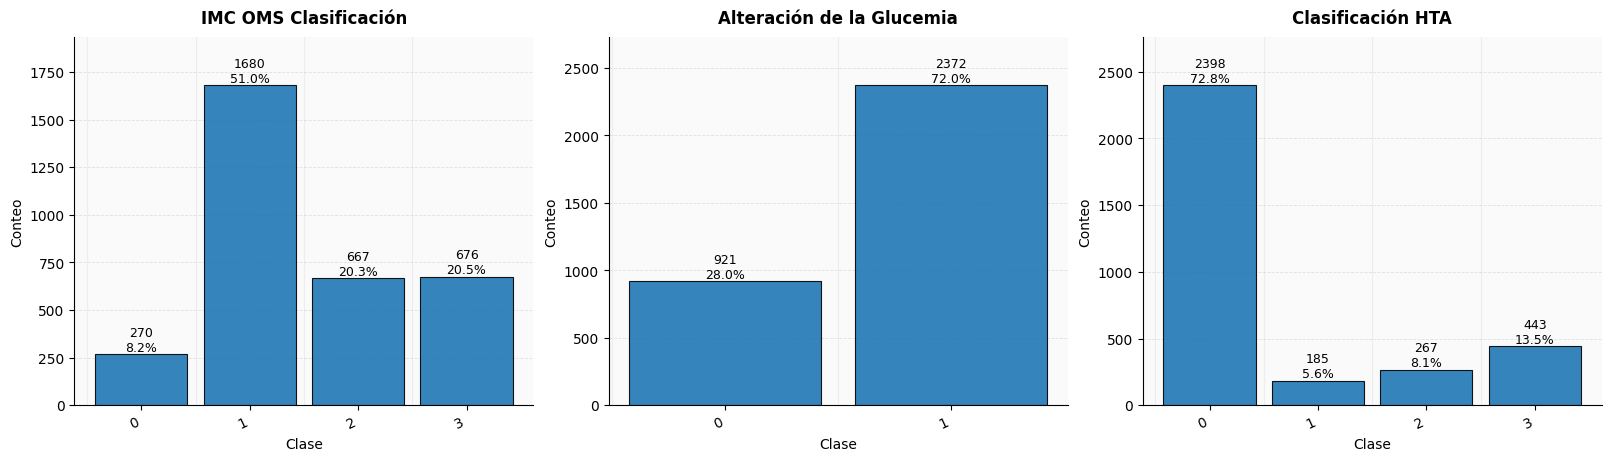

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import textwrap

# ---------- helpers de conteos y estilo ----------
def _counts_in_order(y: pd.Series) -> pd.Series:
    # Respeta el orden si es categórica; si no, ordena por etiqueta
    if pd.api.types.is_categorical_dtype(y):
        return y.value_counts().reindex(y.cat.categories, fill_value=0)
    else:
        return y.value_counts().sort_index()

def _wrap_labels(labels, width=14):
    return ['\n'.join(textwrap.wrap(str(lbl), width=width)) for lbl in labels]

def _nice_bars(ax, x, h, labels, title):
    # barras con borde y ligera transparencia
    bars = ax.bar(x, h, width=0.85, linewidth=0.8, edgecolor='black', alpha=0.9)

    # grid sutil
    ax.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)

    # fondo muy tenue al panel
    ax.set_facecolor((0, 0, 0, 0.02))

    # ejes más limpios
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(_wrap_labels(labels), rotation=25, ha='right')
    ax.set_title(title, pad=10, fontsize=12, weight='bold')

    # headroom para que quepan etiquetas arriba
    ymax = (h.max() * 1.15) if len(h) else 1.0
    ax.set_ylim(0, ymax)

    return bars

def _annotate_counts_percent(ax, bars, counts, total):
    for rect, c in zip(bars, counts):
        y = rect.get_height()
        pct = (c / total * 100.0) if total else 0.0
        ax.text(rect.get_x() + rect.get_width()/2, y,
                f'{c}\n{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)

# ---------- figura 1x3 ----------
def plot_class_histograms(Y1, Y2, Y3, titles=('IMC OMS Clasificación','Alteración de la Glucemia','Clasificación HTA')):
    # un poquito de tipografía global
    mpl.rcParams.update({
        'font.size': 10,
        'axes.titlesize': 12,
        'axes.labelsize': 10
    })

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

    Ys = [Y1, Y2, Y3]
    for ax, y, ttl in zip(axes, Ys, titles):
        counts_s = _counts_in_order(pd.Series(y))
        labels = list(counts_s.index)
        counts = counts_s.to_numpy()
        total = counts.sum()
        x = np.arange(len(labels))

        bars = _nice_bars(ax, x, counts, labels, ttl)
        _annotate_counts_percent(ax, bars, counts, total)

        ax.set_xlabel('Clase')
        ax.set_ylabel('Conteo')

        # líneas verticales tenues para separar barras (si hay muchas)
        for xi in x:
            ax.axvline(xi - 0.5, color=(0,0,0,0.05), linewidth=0.8)

    # fig.suptitle('Distribución de clases (conteo y porcentaje)', y=1.02, fontsize=13, weight='bold')
    plt.show()

# --- uso ---
plot_class_histograms(Y1, Y2, Y3)


In [8]:
cols_obj = X.select_dtypes(include='object').columns.tolist()
X[cols_obj] = X[cols_obj].apply(pd.to_numeric, errors='coerce').astype('float64')

In [9]:
X = dummify(X, cols=['Sexo', 'Codificación Familiares con obesidad', 'Codificación Familiares con DM','Tipo actividad fisica realizada', 'Tipo de Deporte (si corresponde)'], drop_first=True)

In [10]:
X.dtypes

Edad                                                                                  int64
Peso al Nacer                                                                         int64
Horas de sueño                                                                      float64
Duerme menos de 8 horas                                                               int64
Familiares con obesidad                                                               int64
Familiares con DM                                                                     int64
Ganancia del peso del niño de más de > 10 kg en el primer año                       float64
Lactancia Materna                                                                   float64
Ganancia de peso materno en embarazo mayor a 10 kg                                  float64
Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)       float64
Ingesta diaria de alimentos de alto contenido calórico Más de 2 veces por semana

In [11]:
X.describe()

,Edad,Peso al Nacer,Horas de sueño,Duerme menos de 8 horas,Familiares con obesidad,Familiares con DM,Ganancia del peso del niño de más de > 10 kg en el primer año,Lactancia Materna,Ganancia de peso materno en embarazo mayor a 10 kg,"Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)",...,Codificación Familiares con DM__6,Codificación Familiares con DM__7,Tipo actividad fisica realizada__2.0,Tipo actividad fisica realizada__3.0,Tipo de Deporte (si corresponde)__2.0,Tipo de Deporte (si corresponde)__3.0,Tipo de Deporte (si corresponde)__4.0,Tipo de Deporte (si corresponde)__5.0,Tipo de Deporte (si corresponde)__6.0,Tipo de Deporte (si corresponde)__7.0
count,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3288.000000,3292.000000,3281.000000,3286.000000,...,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000
mean,10.958397,2.058913,8.303097,0.191315,0.422411,0.488309,0.212895,0.356622,0.345017,0.654900,...,0.000304,0.010932,0.393258,0.122381,0.032493,0.054965,0.027027,0.008503,0.071060,0.053750
std,2.878847,0.423551,1.217519,0.393396,0.494018,0.499939,0.409417,0.479075,0.475446,0.475473,...,0.017426,0.104000,0.488548,0.327775,0.177333,0.227947,0.162187,0.091832,0.256964,0.225559
min,5.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,2.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,2.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,13.000000,2.000000,9.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,3.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
report = dqr(X)
report

,Name,Type,N/A value,Count values,Unique values,Min,Max,Mean,Std,Var,Median,Skewness,Kurtosis
Edad,Edad,int64,0,3293,12,5.000000,16.000000,10.958397,2.878847,8.287758e+00,11.000000,-0.001242,-0.981974
Peso al Nacer,Peso al Nacer,int64,0,3293,3,1.000000,3.000000,2.058913,0.423551,1.793958e-01,2.000000,0.355821,2.374897
Horas de sueño,Horas de sueño,float64,0,3293,19,3.000000,13.000000,8.303097,1.217519,1.482354e+00,8.000000,0.159595,1.123722
Duerme menos de 8 horas,Duerme menos de 8 horas,int64,0,3293,2,0.000000,1.000000,0.191315,0.393396,1.547605e-01,0.000000,1.570288,0.466088
Familiares con obesidad,Familiares con obesidad,int64,0,3293,2,0.000000,1.000000,0.422411,0.494018,2.440541e-01,0.000000,0.314304,-1.902369
Familiares con DM,Familiares con DM,int64,0,3293,2,0.000000,1.000000,0.488309,0.499939,2.499392e-01,0.000000,0.046800,-1.999024
Ganancia del peso del niño de más de > 10 kg en el primer año,Ganancia del peso del niño de más de > 10 kg e...,float64,5,3288,2,0.000000,1.000000,0.212895,0.409417,1.676219e-01,0.000000,1.403360,-0.030600
Lactancia Materna,Lactancia Materna,float64,1,3292,2,0.000000,1.000000,0.356622,0.479075,2.295125e-01,0.000000,0.598926,-1.642286
Ganancia de peso materno en embarazo mayor a 10 kg,Ganancia de peso materno en embarazo mayor a 1...,float64,12,3281,2,0.000000,1.000000,0.345017,0.475446,2.260491e-01,0.000000,0.652346,-1.575405
"Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)","Más de dos horas ante pantalla diaria (TV, vid...",float64,7,3286,2,0.000000,1.000000,0.654900,0.475473,2.260749e-01,1.000000,-0.651956,-1.575913


In [13]:
counts = Y1.value_counts()
print("IMC OMS Clasificación")
print("Cantidad de 0:", counts.get(0, 0), "Cantidad de 1:", counts.get(1, 0), "Cantidad de 2:", counts.get(2, 0), "Cantidad de 3:", counts.get(3, 0))
counts = Y2.value_counts()
print("Alteración")
print("Cantidad de 0:", counts.get(0, 0), "Cantidad de 1:", counts.get(1, 0))
counts = Y3.value_counts()
print("HTA")
print("Cantidad de 0:", counts.get(0, 0), "Cantidad de 1:", counts.get(1, 0), "Cantidad de 2:", counts.get(2, 0), "Cantidad de 3:", counts.get(3, 0))

IMC OMS Clasificación
Cantidad de 0: 270 Cantidad de 1: 1680 Cantidad de 2: 667 Cantidad de 3: 676
Alteración
Cantidad de 0: 921 Cantidad de 1: 2372
HTA
Cantidad de 0: 2398 Cantidad de 1: 185 Cantidad de 2: 267 Cantidad de 3: 443


In [14]:
len(Y1)

3293

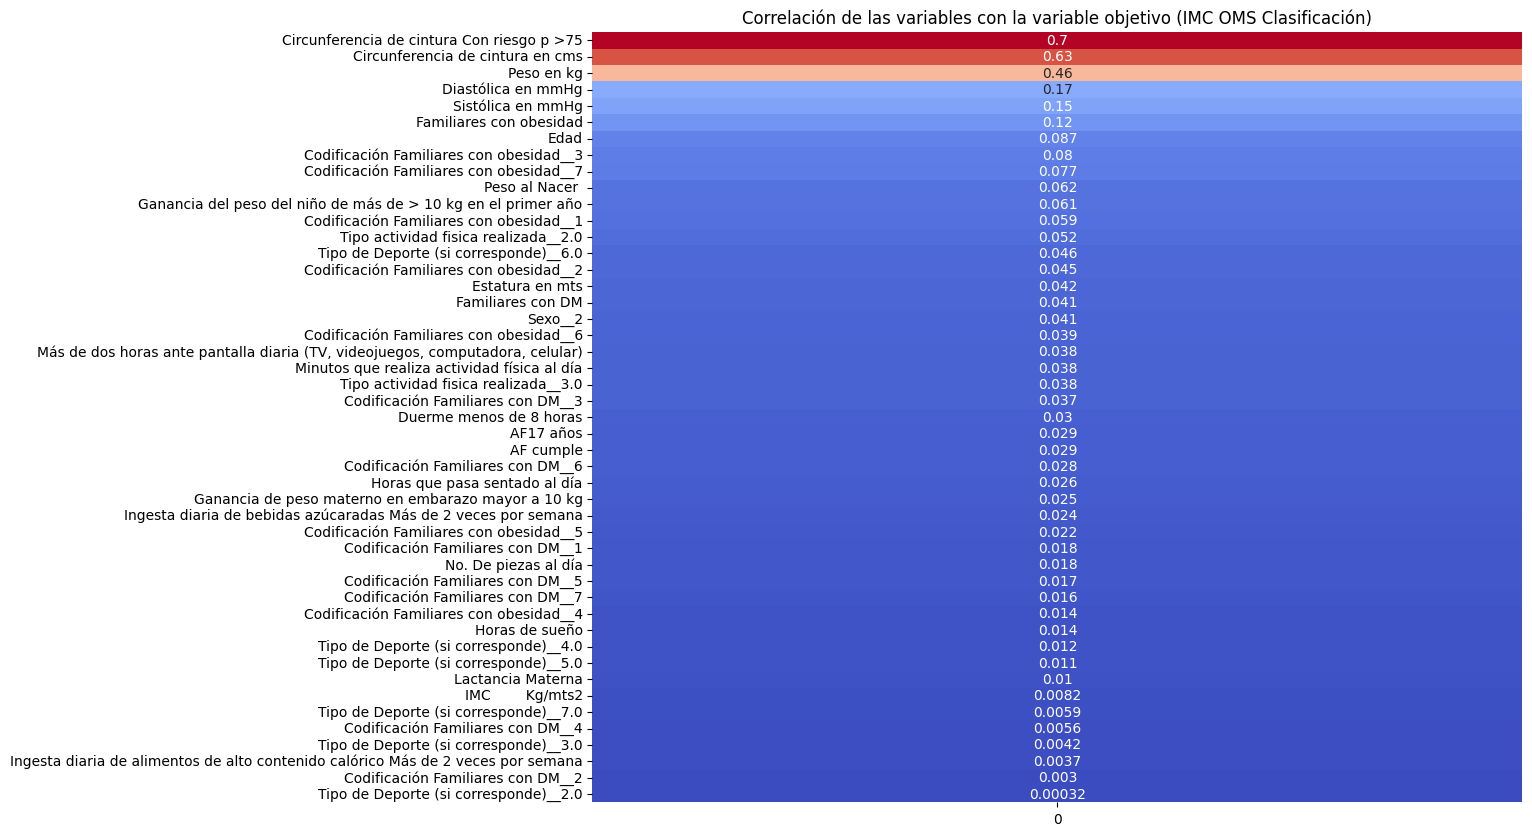

In [15]:
plt.figure(figsize=(12,10))
correlation_matrix = X.corrwith(Y1).abs().sort_values(ascending=False)
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlación de las variables con la variable objetivo (IMC OMS Clasificación)')
plt.show()

In [16]:
correlation_matrix.head()

Circunferencia de cintura Con riesgo p >75    0.696525
Circunferencia de cintura en cms              0.625248
Peso en kg                                    0.464969
Diastólica en mmHg                            0.165622
Sistólica en mmHg                             0.147791
dtype: float64

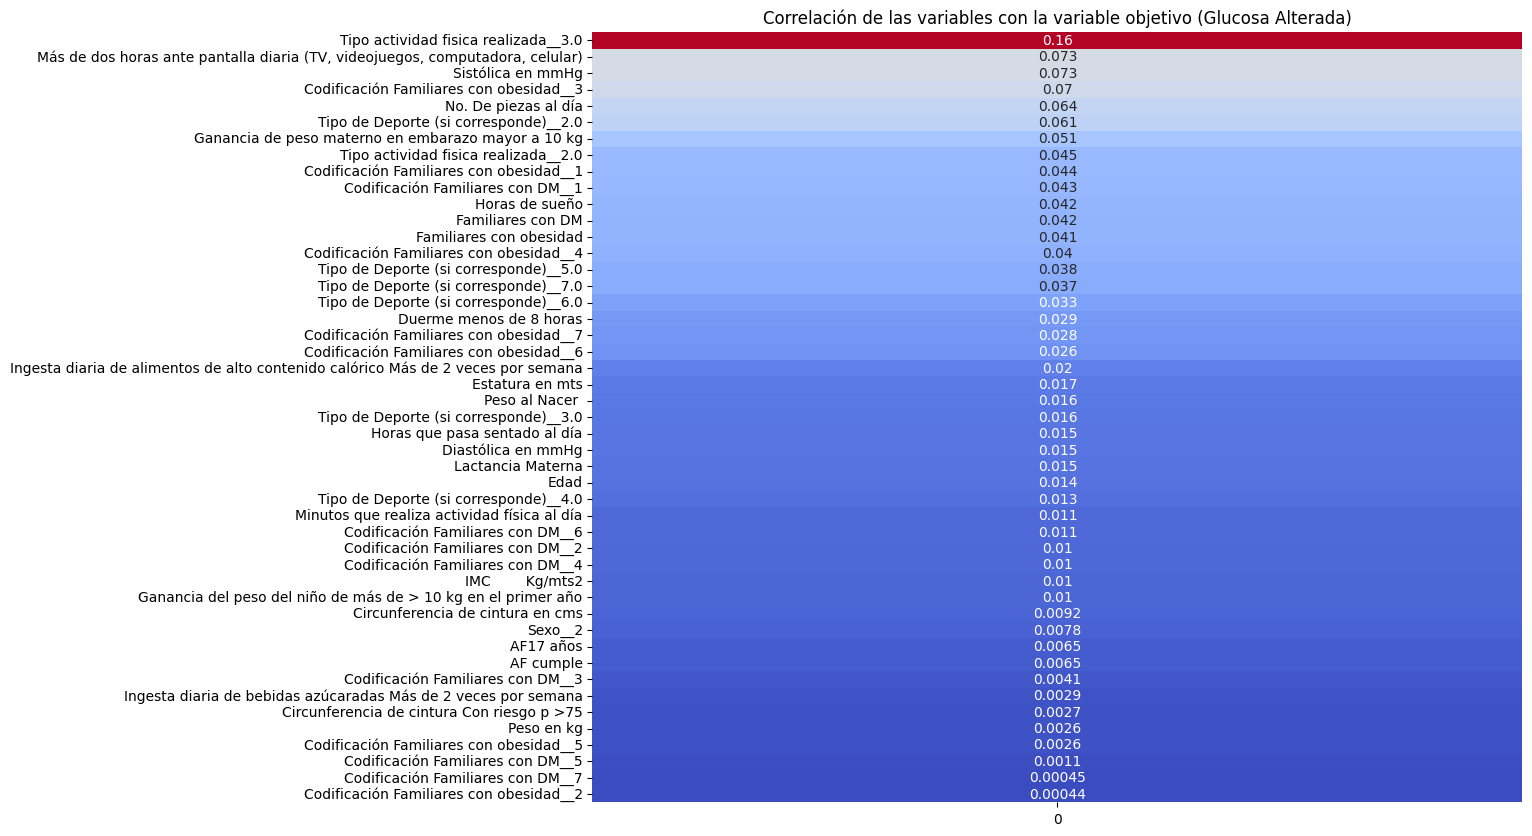

In [17]:
plt.figure(figsize=(12,10))
correlation_matrix = X.corrwith(Y2).abs().sort_values(ascending=False)
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlación de las variables con la variable objetivo (Glucosa Alterada)')
plt.show()

In [18]:
correlation_matrix.head()

Tipo actividad fisica realizada__3.0                                             0.155426
Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)    0.073414
Sistólica en mmHg                                                                0.072527
Codificación Familiares con obesidad__3                                          0.070019
No. De piezas al día                                                             0.064057
dtype: float64

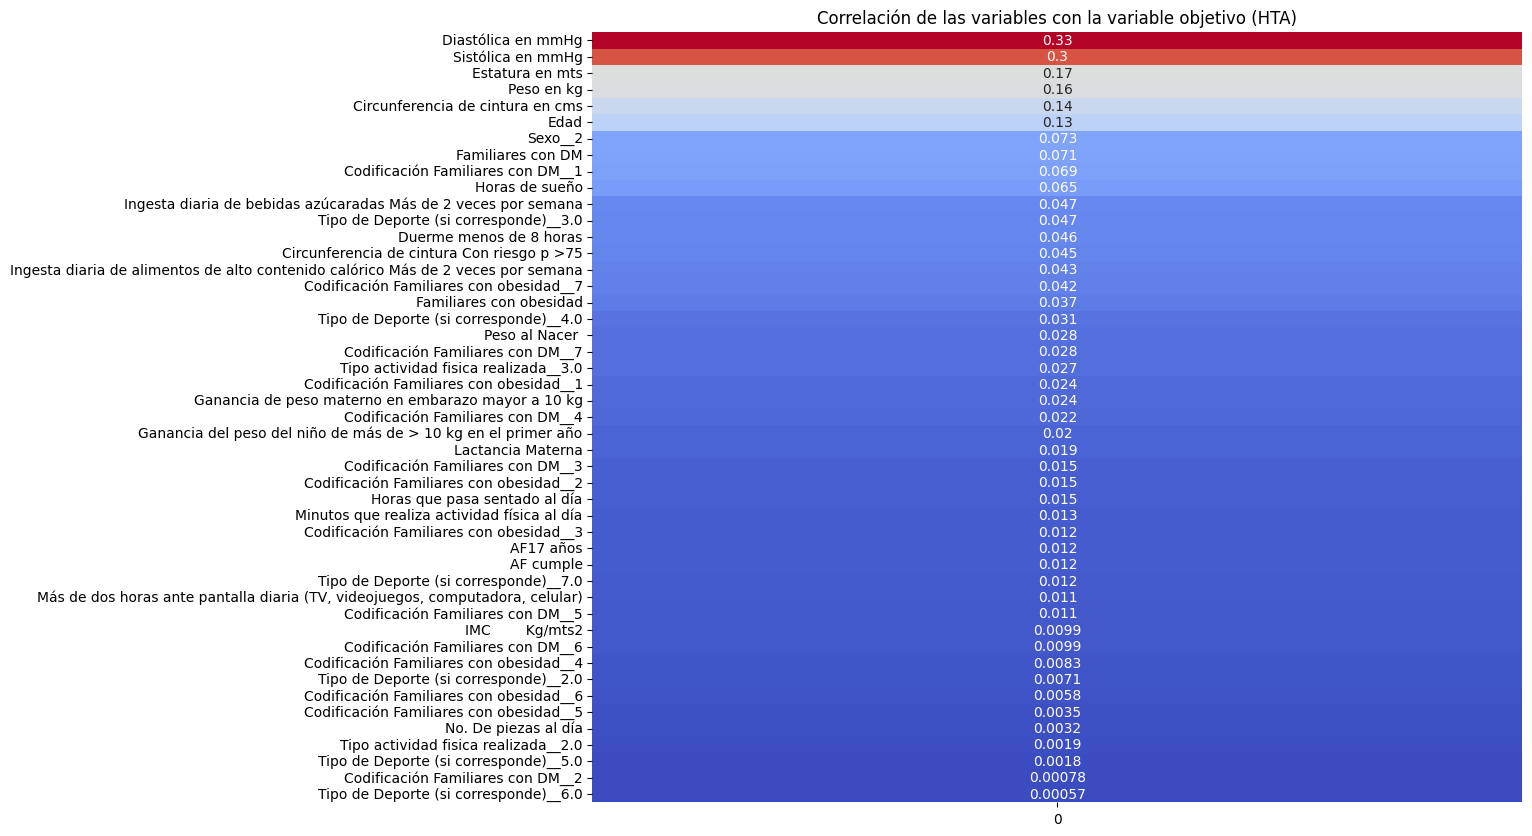

In [19]:
plt.figure(figsize=(12,10))
correlation_matrix = X.corrwith(Y3).abs().sort_values(ascending=False)
sns.heatmap(correlation_matrix.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlación de las variables con la variable objetivo (HTA)')
plt.show()

In [20]:
correlation_matrix.head()

Diastólica en mmHg                  0.331461
Sistólica en mmHg                   0.296605
Estatura en mts                     0.165449
Peso en kg                          0.162717
Circunferencia de cintura en cms    0.143468
dtype: float64

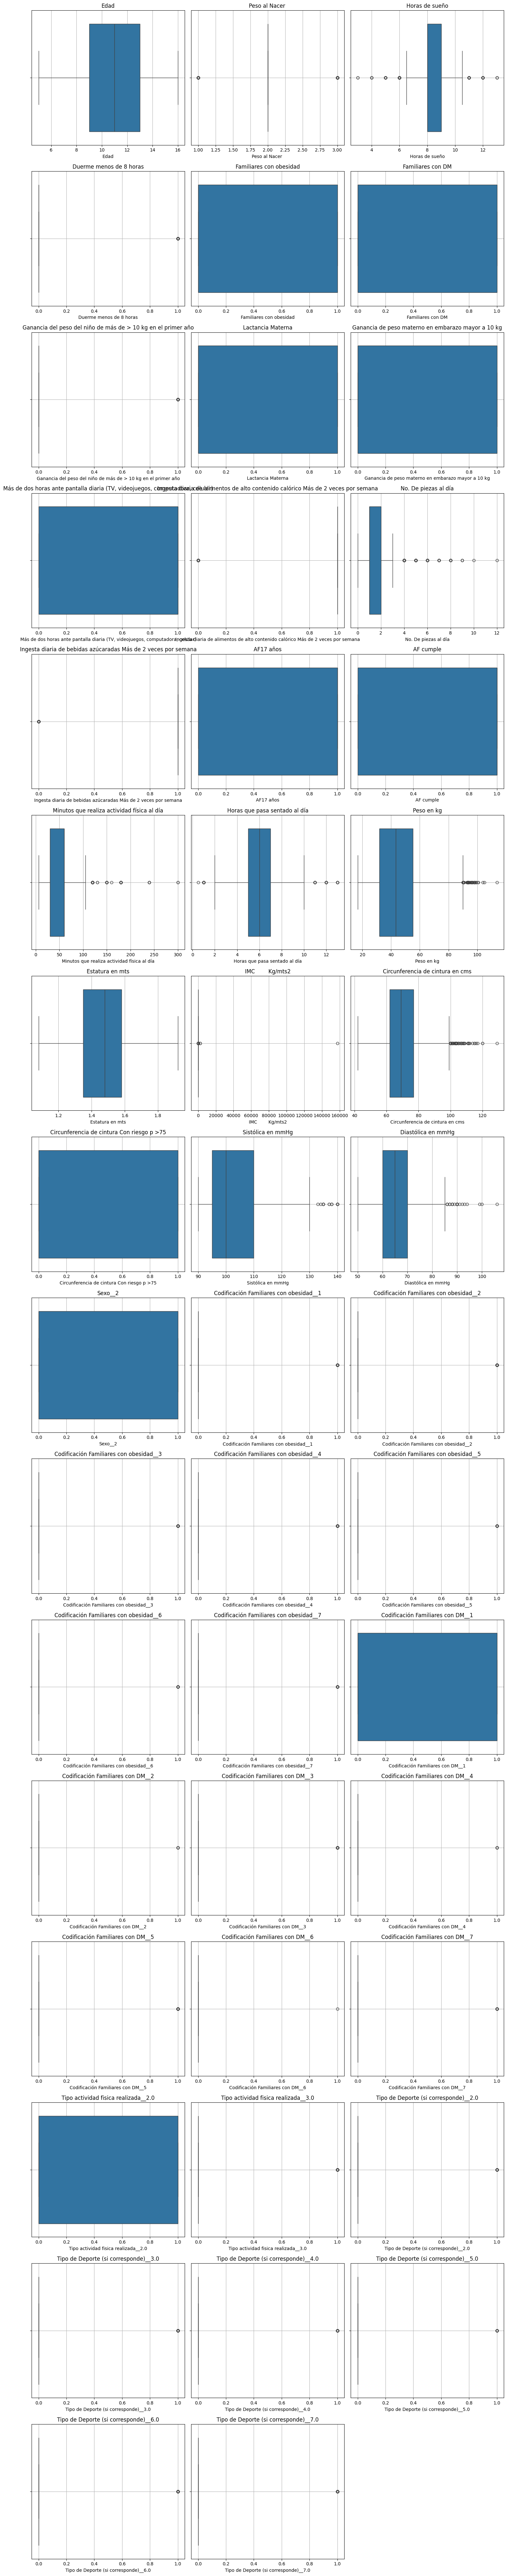

In [21]:
valid_columns = [col for col in X.columns if pd.api.types.is_numeric_dtype(X[col]) and X[col].notna().any()]

n_cols = 3
n_rows = (len(valid_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(valid_columns):
    sns.boxplot(x=X[col], ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_title(col)
    axes[i].grid(True)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
for col in ['IMC        Kg/mts2']:
    merged = pd.concat([X, Y1, Y2, Y3], axis=1)
    cleaned = drop_outliers_iqr(merged, col)
    X = cleaned[X.columns]
    Y1 = cleaned[Y1.name]
    Y2 = cleaned[Y2.name]
    Y3 = cleaned[Y3.name]

In [23]:
X_nonan = X.loc[:, X.notna().any()]
column_names = X_nonan.columns

if X_nonan.isnull().any().any():
    imputer = SimpleImputer(strategy="median")
    imputer.fit(X_nonan)
    X_imputed = imputer.transform(X_nonan)
    X = pd.DataFrame(X_imputed, columns=column_names)
else:
    print("No se encontraron valores faltantes; no se aplica imputación.")

In [24]:
len(Y1)

3229

In [25]:
X_  = X.reset_index(drop=True)
Y1_ = Y1.reset_index(drop=True)
Y2_ = Y2.reset_index(drop=True)
Y3_ = Y3.reset_index(drop=True)

# 2) Split 50% train / 50% resto, estratificado por Y1
X_train, X_rest, Y1_train, Y1_rest, Y2_train, Y2_rest, Y3_train, Y3_rest = train_test_split(
    X_, Y1_, Y2_, Y3_,
    test_size=0.6, random_state=42, stratify=Y1_
)

# 3) Split 50/50 del resto → 25% val / 25% test, también estratificado por Y1
X_test, X_val, Y1_test, Y1_val, Y2_test, Y2_val, Y3_test, Y3_val = train_test_split(
    X_rest, Y1_rest, Y2_rest, Y3_rest,
    test_size=0.5, random_state=42, stratify=Y1_rest
)


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple
from sklearn.base import BaseEstimator

def _coef_matrix_and_classes(model: BaseEstimator):
    coef = np.asarray(model.coef_)
    classes = np.asarray(getattr(model, "classes_", np.arange(coef.shape[0])))
    return coef, classes

def _aggregate_multiclass(coef: np.ndarray, how: str = "abs_mean") -> np.ndarray:
    if coef.ndim == 1:
        return np.abs(coef)
    return (np.abs(coef).max(axis=0) if how == "abs_max" else np.abs(coef).mean(axis=0))

def _shorten(s: str, max_chars: int = 28) -> str:
    s = str(s)
    return s if len(s) <= max_chars else s[:max_chars-1] + "…"

def plot_logreg_coefs_panel_safe(
    models: Dict[str, BaseEstimator],
    feature_names: List[str],
    top_k: int = 15,
    multiclass_agg: str = "abs_mean",   # 'abs_mean' | 'abs_max'
    max_fig_w: float = 18.0,            # inches (tope ancho)
    max_fig_h: float = 9.0,             # inches (tope alto)
    label_max_chars: int = 28
):
    # ---- tamaño de figura calculado pero limitado ----
    n_models = len(models)
    # ancho base por panel ~5", pero cap a max_fig_w
    fig_w = min(max_fig_w, max(6.0, 5.0 * n_models))
    # alto en función de top_k (0.4" por barra) pero cap a max_fig_h
    fig_h = min(max_fig_h, max(3.8, 0.42 * top_k + 1.2))

    fig, axes = plt.subplots(1, n_models, figsize=(fig_w, fig_h))
    if n_models == 1:
        axes = [axes]

    for ax, (name, mdl) in zip(axes, models.items()):
        coef, classes = _coef_matrix_and_classes(mdl)  # (C,F) o (1,F)
        if coef.ndim == 2:  # multiclase
            signed = coef.mean(axis=0)
            imp = _aggregate_multiclass(coef, multiclass_agg)
        else:
            signed = coef.ravel()
            imp = np.abs(signed)

        idx = np.argsort(imp)[::-1][:top_k]
        feats = [feature_names[i] for i in idx]
        vals_signed = signed[idx]
        vals_abs = imp[idx]

        order = np.argsort(vals_abs)  # para que salgan de abajo->arriba
        feats = [ _shorten(feats[i], label_max_chars) for i in order ]
        vals_signed = vals_signed[order]
        vals_abs = vals_abs[order]

        y = np.arange(len(feats))
        colors = np.where(vals_signed >= 0, "#2e8b57", "#c0392b")

        ax.barh(y, vals_signed, edgecolor="black", linewidth=0.7, alpha=0.9, color=colors)
        ax.set_yticks(y)
        ax.set_yticklabels(feats)
        ax.set_title(f"{name} — Top {top_k} coef", fontsize=12, weight="bold")
        ax.axvline(0, color="black", linewidth=0.8)
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

        # margen lateral para que quepan las etiquetas de valor
        x_max = max(1e-9, np.max(np.abs(vals_signed)))
        ax.set_xlim(-x_max*1.25, x_max*1.25)

        # anotar valor
        for yi, v in zip(y, vals_signed):
            ax.text(v + (0.02 * x_max if v >= 0 else -0.02 * x_max),
                    yi, f"{v:.3f}",
                    va="center",
                    ha="left" if v >= 0 else "right",
                    fontsize=9)

        ax.set_xlabel("Peso del coeficiente (±)")

    fig.suptitle("Importancia (coeficientes) por modelo — signo y magnitud",
                 fontsize=13, weight="bold", y=0.995)
    # Evita constrained_layout; usa un tight_layout controlado para no inflar la figura
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



In [27]:
logreg_model = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model.fit(X_train, Y1_train)
metrics_df, roc_corner = metrics( logreg_model, X_train, X_test, X_val, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.776917  0.737874  0.729618
Precision (thr*)  0.714089  0.676465  0.674473
Recall (thr*)     0.752790  0.711671  0.708515
ROC AUC           0.934644  0.914077  0.915658

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.093346  0.210586  0.864198  0.250577
1      1   0.591634  0.214592  0.844930  0.264757
2      2   0.203663  0.234070  0.890000  0.258629
3      3   0.237555  0.071429  0.951351  0.086422


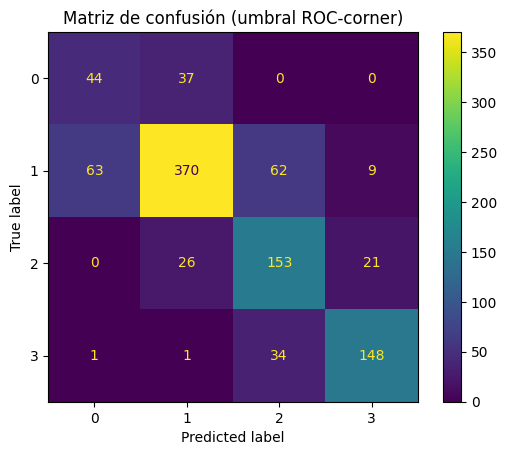

In [28]:
confusion_matrix_mult(logreg_model, Y1_train, X_test, Y1_test, X_val, Y1_val)

In [29]:
coef_imp = lr_coef_importance(logreg_model, X_train, estandarizar=True)
display(coef_imp.head(20))

c:\Users\luill\OneDrive\Documentos\Maestría Ciencia de Datos\Tesis\funciones.py:389: RuntimeWarning: invalid value encountered in divide
  z_theta = theta / se_theta


,class,ref_class,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
0,0,3,IMC Kg/mts2,-2.466665,0.084867,0.321715,-7.667241,1.754152e-14,-10.049150,10.049150,0.000043
1,0,3,Edad,2.180323,8.849162,0.198110,11.005642,0.000000e+00,6.338598,6.338598,566.002478
2,0,3,Peso en kg,-0.131220,0.877024,0.130515,-1.005408,3.147005e-01,-2.040495,2.040495,0.129964
3,0,3,Horas de sueño,1.014064,2.756781,0.247227,4.101755,4.100275e-05,1.237866,1.237866,3.448246
4,0,3,Duerme menos de 8 horas,2.562469,12.967789,0.739032,3.467333,5.256511e-04,1.020193,1.020193,2.773730
5,0,3,Sistólica en mmHg,0.089591,1.093727,0.023880,3.751675,1.756569e-04,0.928566,0.928566,2.530878
6,0,3,Circunferencia de cintura en cms,0.066712,1.068987,0.047962,1.390930,1.642467e-01,0.771540,0.771540,2.163096
7,0,3,Circunferencia de cintura Con riesgo p >75,-1.296531,0.273479,0.904409,-1.433567,1.516959e-01,-0.608537,0.608537,0.544147
8,0,3,Horas que pasa sentado al día,0.257912,1.294225,0.118462,2.177175,2.946748e-02,0.469414,0.469414,1.599057
9,0,3,Peso al Nacer,1.107345,3.026312,0.543379,2.037887,4.156123e-02,0.443153,0.443153,1.557611


In [30]:
logreg_model2 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model2.fit(X_train, Y2_train)
metrics_df, roc_corner = metrics( logreg_model2, X_train, X_test, X_val, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.605732  0.563467  0.603715
Precision (thr*)  0.814371  0.768482  0.782609
Recall (thr*)     0.585576  0.565093  0.620690
ROC AUC           0.670569  0.596869  0.609727

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold      FPR      TPR  distance
0      1   0.725967  0.43956  0.62069  0.580594


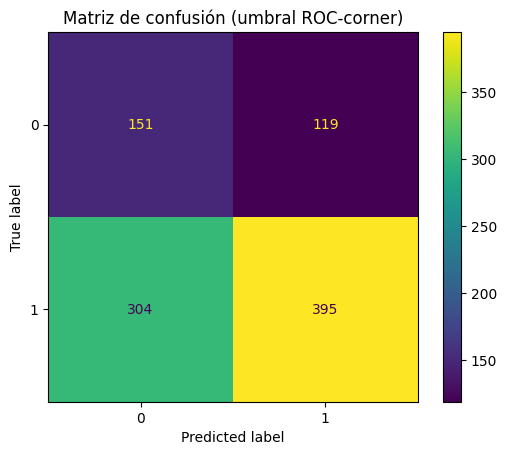

In [31]:
confusion_matrix_binary(logreg_model2, X_test, Y2_test, X_val, Y2_val)

In [32]:
coef_imp2 = lr_coef_importance(logreg_model2, X_train, estandarizar=True)
display(coef_imp2.head(20))

,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
0,Tipo actividad fisica realizada__3.0,-0.845060,0.429531,0.228002,-3.706373,0.000210,-0.279941,0.279941,0.755829
1,Sistólica en mmHg,0.023835,1.024122,0.007723,3.086383,0.002026,0.247040,0.247040,1.280231
2,Horas de sueño,0.151386,1.163445,0.082459,1.835884,0.066375,0.184796,0.184796,1.202973
3,Diastólica en mmHg,-0.023229,0.977039,0.009863,-2.355047,0.018520,-0.176074,0.176074,0.838556
4,Codificación Familiares con obesidad__4,-0.469804,0.625125,1.079681,-0.435133,0.663466,-0.168588,0.168588,0.844857
5,Familiares con obesidad,0.342102,1.407905,1.078973,0.317063,0.751196,0.168242,0.168242,1.183223
6,Tipo de Deporte (si corresponde)__7.0,-0.681420,0.505898,0.282293,-2.413876,0.015784,-0.163325,0.163325,0.849315
7,Tipo de Deporte (si corresponde)__2.0,-0.899956,0.406588,0.347677,-2.588487,0.009640,-0.159662,0.159662,0.852432
8,Tipo de Deporte (si corresponde)__4.0,-0.891975,0.409846,0.374221,-2.383550,0.017147,-0.150763,0.150763,0.860052
9,Familiares con DM,0.300790,1.350925,0.260342,1.155363,0.247942,0.149897,0.149897,1.161714


In [33]:
logreg_model3 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=3000)
logreg_model3.fit(X_train, Y3_train)
metrics_df, roc_corner = metrics( logreg_model3, X_train, X_test, X_val, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.691712  0.621259  0.629515
Precision (thr*)  0.538261  0.450289  0.482574
Recall (thr*)     0.668595  0.558017  0.574244
ROC AUC           0.871422  0.798624  0.809469

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.719017  0.353571  0.808418  0.402140
1      1   0.064047  0.146608  0.872727  0.194145
2      2   0.117348  0.100565  0.928571  0.123351
3      3   0.098018  0.455314  0.631206  0.585935


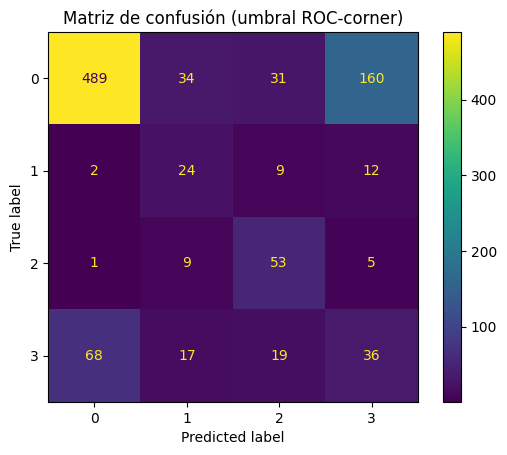

In [34]:
confusion_matrix_mult(logreg_model3, Y3_train, X_test, Y3_test, X_val, Y3_val)

In [35]:
coef_imp3 = lr_coef_importance(logreg_model3, X_train, estandarizar=True)
display(coef_imp3.head(20))

c:\Users\luill\OneDrive\Documentos\Maestría Ciencia de Datos\Tesis\funciones.py:389: RuntimeWarning: invalid value encountered in divide
  z_theta = theta / se_theta


,class,ref_class,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
0,0,3,Peso en kg,0.036424,1.037096,0.048388,0.752751,0.451599,0.566401,0.566401,1.761915
1,0,3,Estatura en mts,-3.368789,0.034431,3.147409,-1.070337,0.284468,-0.540058,0.540058,0.582714
2,0,3,Sistólica en mmHg,-0.043933,0.957018,0.011185,-3.927987,0.000086,-0.455340,0.455340,0.634233
3,0,3,Circunferencia de cintura Con riesgo p >75,-0.630114,0.532531,0.338331,-1.862421,0.062544,-0.295749,0.295749,0.743974
4,0,3,Horas de sueño,0.180195,1.197451,0.117632,1.531855,0.125558,0.219963,0.219963,1.246031
5,0,3,Edad,-0.074921,0.927817,0.073920,-1.013540,0.310802,-0.217809,0.217809,0.804279
6,0,3,Tipo actividad fisica realizada__2.0,0.403062,1.496399,0.239098,1.685762,0.091842,0.197108,0.197108,1.217875
7,0,3,Ingesta diaria de bebidas azúcaradas Más de 2 ...,-0.413121,0.661582,0.271004,-1.524410,0.127406,-0.171130,0.171130,0.842712
8,0,3,Sexo__2,-0.341026,0.711040,0.205576,-1.658884,0.097139,-0.170512,0.170512,0.843233
9,0,3,Circunferencia de cintura en cms,-0.012670,0.987410,0.018342,-0.690779,0.489704,-0.146533,0.146533,0.863697


In [36]:
logreg_model2.coef_

array([[-0.0145652 ,  0.02924407,  0.15138557, -0.02139525,  0.34210244,
         0.30078968, -0.096754  , -0.00997054,  0.06526887, -0.15196929,
         0.13919192,  0.04429584, -0.15499388, -0.15379319, -0.15379319,
         0.0030607 ,  0.00618647,  0.00557068, -0.59280804, -0.03540372,
         0.01050796,  0.02912101,  0.02383531, -0.02322863, -0.10479912,
         0.31960301, -0.35683515,  0.49602312, -0.46980439,  0.2301988 ,
        -0.08782746,  0.36674862, -0.15195987, -0.34070293, -0.33432181,
        -0.25378153,  0.09945864,  0.        ,  0.68761273, -0.22569722,
        -0.8450604 , -0.89995604, -0.20817671, -0.89197499, -0.96743044,
         0.21781752, -0.68141954]])

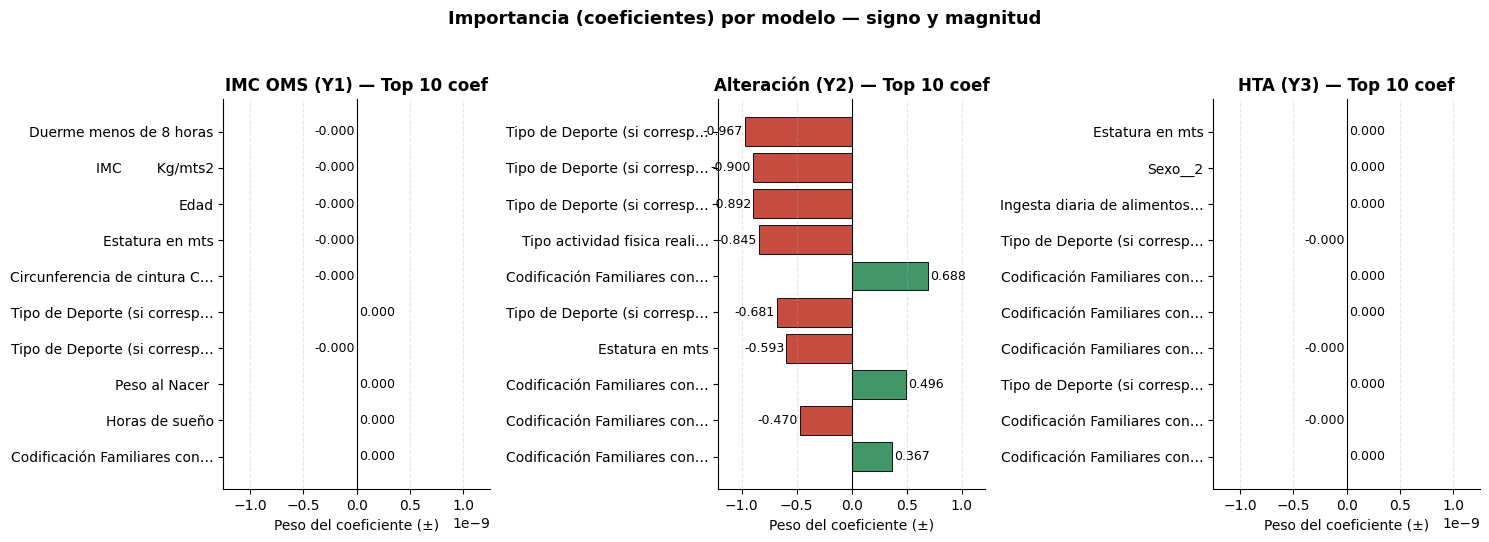

In [37]:
feature_names = list(X_train.columns)  # mismo orden del entrenamiento
models = {
    "IMC OMS (Y1)": logreg_model,
    "Alteración (Y2)": logreg_model2,
    "HTA (Y3)": logreg_model3,
}
plot_logreg_coefs_panel_safe(models, feature_names, top_k=10)

### Regresión logística binaria

Para $y_i\in{0,1}$ y función sigmoide $\sigma(t)=\frac{1}{1+e^{-t}}$:

**Modelo**
$$
\mathbb{P}(y_i=1\mid \mathbf{x}_i)=\sigma(\mathbf{x}_i^\top\boldsymbol{\beta}).
$$

**Log-verosimilitud / Pérdida (entropía cruzada)**
$$
\ell(\boldsymbol{\beta})=\sum_{i=1}^n\Big[
y_i,\mathbf{x}_i^\top\boldsymbol{\beta}-\log!\big(1+e^{\mathbf{x}_i^\top\boldsymbol{\beta}}\big)\Big],
\qquad
\mathcal{L}(\boldsymbol{\beta})=-\ell(\boldsymbol{\beta}).
$$

**Gradiente**
$$
\nabla \mathcal{L}(\boldsymbol{\beta})=\mathbf{X}^\top(\hat{\mathbf{p}}-\mathbf{y}),
\quad \hat{\mathbf{p}}=\sigma(\mathbf{X}\boldsymbol{\beta}).
$$

---

### Regresión logística multinomial (multiclase)

Para $K$ clases, $y_i\in{1,\dots,K}$, y parámetros $\boldsymbol{\beta}_k\in\mathbb{R}^p$:

**Modelo (softmax)**
$$
\mathbb{P}(y_i=k\mid \mathbf{x}_i)
=\frac{\exp(\mathbf{x}_i^\top\boldsymbol{\beta}*k)}
{\sum*{j=1}^{K}\exp(\mathbf{x}_i^\top\boldsymbol{\beta}_j)},\quad k=1,\dots,K.
$$

> Identificación: fijar, p. ej., $\boldsymbol{\beta}_K=\mathbf{0}$.

**Log-verosimilitud / Pérdida**
$$
\ell({\boldsymbol{\beta}*k})=
\sum*{i=1}^{n}\sum_{k=1}^{K}\mathbf{1}{y_i=k}
\left[\mathbf{x}_i^\top\boldsymbol{\beta}*k-
\log!\Big(\sum*{j=1}^{K}e^{\mathbf{x}_i^\top\boldsymbol{\beta}_j}\Big)\right],
\qquad
\mathcal{L}=-\ell.
$$

**Gradiente por clase $k$**
$$
\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}_k}
=\mathbf{X}^\top!\left(\hat{\mathbf{p}}_k-\mathbf{y}*k\right),
\quad
\hat{p}*{ik}=\frac{e^{\mathbf{x}_i^\top\boldsymbol{\beta}*k}}{\sum*{j}e^{\mathbf{x}_i^\top\boldsymbol{\beta}_j}},
\quad
(\mathbf{y}_k)_i=\mathbf{1}{y_i=k}.
$$

**Regla de decisión**
$$
\hat{y}*i=\arg\max*{k},\hat{p}_{ik}.
$$

**Regularización (opcional)**
$$
\mathcal{L}*\lambda=
-\ell+\lambda\sum*{k=1}^K|\boldsymbol{\beta}*k|*2^2
\quad\text{(ridge)},
\qquad
\mathcal{L}*{\lambda,\alpha}=
-\ell+\lambda\sum*{k=1}^K\Big(\alpha|\boldsymbol{\beta}_k|_1+\tfrac{1}{2}(1-\alpha)|\boldsymbol{\beta}_k|_2^2\Big).
$$

---


# `Quitando variables no significativas de X`

In [38]:
significant_features_Y1 = coef_imp[coef_imp["p>|z|"] < 0.05].feature
significant_features_Y2 = coef_imp2[coef_imp2["p>|z|"] < 0.05].feature
significant_features_Y3 = coef_imp3[coef_imp3["p>|z|"] < 0.05].feature

In [39]:
# Sólo dejar las variables significativas en X según Y1, Y2 y Y3 sin duplicados
X_train_significant1 = X_train[list(set(significant_features_Y1))]
X_test_significant1 = X_test[list(set(significant_features_Y1))]
X_val_significant1 = X_val[list(set(significant_features_Y1))]

X_train_significant2 = X_train[list(set(significant_features_Y2))]
X_test_significant2 = X_test[list(set(significant_features_Y2))]
X_val_significant2 = X_val[list(set(significant_features_Y2))]

X_train_significant3 = X_train[list(set(significant_features_Y3))]
X_test_significant3 = X_test[list(set(significant_features_Y3))]
X_val_significant3 = X_val[list(set(significant_features_Y3))]

X_train_significant2.head()

,Sistólica en mmHg,Diastólica en mmHg,Tipo de Deporte (si corresponde)__2.0,Tipo de Deporte (si corresponde)__7.0,Tipo de Deporte (si corresponde)__4.0,Tipo actividad fisica realizada__3.0
496,96.0,62.0,0.0,0.0,0.0,0.0
2367,110.0,80.0,0.0,0.0,0.0,0.0
2695,110.0,70.0,0.0,0.0,0.0,0.0
1441,110.0,60.0,0.0,0.0,0.0,0.0
3098,100.0,60.0,1.0,0.0,0.0,0.0


In [40]:
logreg_model_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model_est.fit(X_train_significant1, Y1_train)
metrics_df, roc_corner = metrics( logreg_model_est, X_train_significant1, X_test_significant1, X_val_significant1, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.769171  0.744066  0.738906
Precision (thr*)  0.698872  0.675856  0.670052
Recall (thr*)     0.725574  0.702345  0.697949
ROC AUC           0.924232  0.913686  0.913371

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.094090  0.211712  0.851852  0.258398
1      1   0.581207  0.223176  0.860835  0.263010
2      2   0.284111  0.167750  0.880000  0.206253
3      3   0.256161  0.079082  0.962162  0.087668


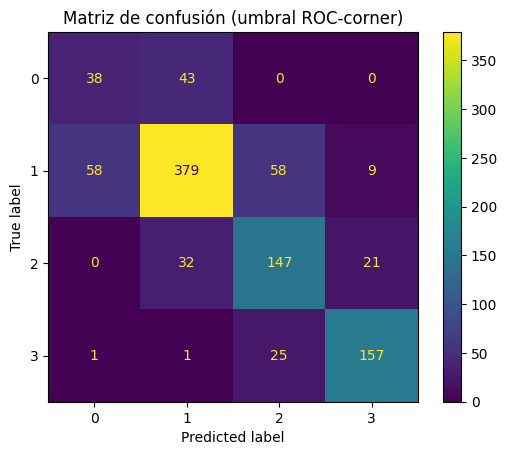

In [41]:
confusion_matrix_mult(logreg_model_est, Y1_train, X_test_significant1, Y1_test, X_val_significant1, Y1_val)

In [42]:
logreg_model2_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model2_est.fit(X_train_significant2, Y2_train)
metrics_df, roc_corner = metrics( logreg_model2_est, X_train_significant2, X_test_significant2, X_val_significant2, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)
logreg_model2_est.coef_

                     Train      Test       Val
Accuracy (thr*)   0.557707  0.552116  0.545924
Precision (thr*)  0.770393  0.766600  0.758065
Recall (thr*)     0.548977  0.545064  0.540230
ROC AUC           0.608631  0.578069  0.575418

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold      FPR      TPR  distance
0      1   0.736075  0.43956  0.54023  0.636083


array([[ 0.0215203 , -0.02431587, -0.9170796 , -0.6360838 , -0.79890101,
        -0.64282661]])

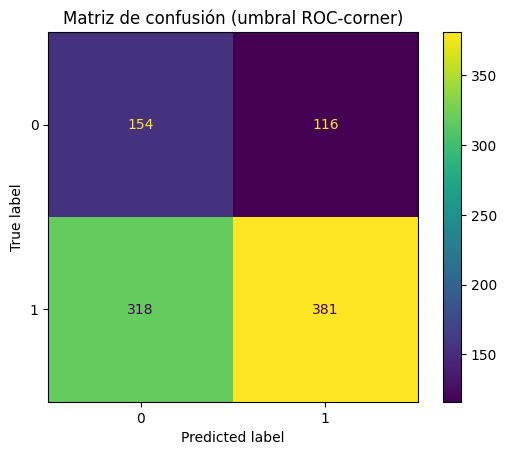

In [43]:
confusion_matrix_binary(logreg_model2_est, X_test_significant2, Y2_test, X_val_significant2, Y2_val)


In [44]:
logreg_model3_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model3_est.fit(X_train_significant3, Y3_train)
metrics_df, roc_corner = metrics( logreg_model3_est, X_train_significant3, X_test_significant3, X_val_significant3, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.646011  0.618163  0.604747
Precision (thr*)  0.470472  0.433823  0.430213
Recall (thr*)     0.572779  0.548671  0.496340
ROC AUC           0.840118  0.794518  0.795161

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.708121  0.342857  0.798258  0.397807
1      1   0.052428  0.193654  0.909091  0.213931
2      2   0.084529  0.149153  0.928571  0.165374
3      3   0.087729  0.466184  0.595745  0.617049


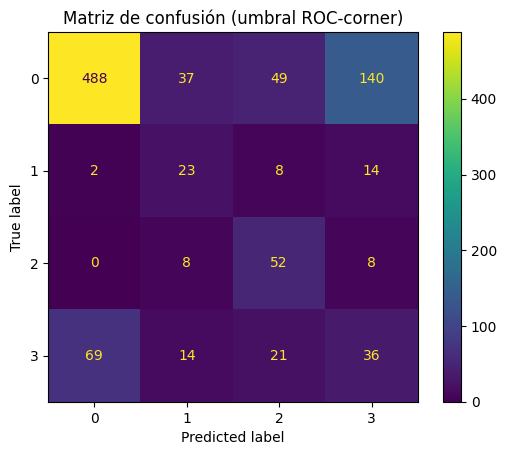

In [45]:
confusion_matrix_mult(logreg_model3_est, Y3_train, X_test_significant3, Y3_test, X_val_significant3, Y3_val)

# `SVM como modelo de comparación`

In [46]:
search1 = svc_hiper_search_mult(X_train_significant1, Y1_train)
best_model1 = search1.best_estimator_
print("Mejores hiperparámetros:", search1.best_params_)
print("Mejor f1_macro (CV):", search1.best_score_)

metrics_df, roc_corner = metrics( best_model1, X_train_significant1, X_test_significant1, X_val_significant1, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(639.6653397497474), 'svc__cache_size': 500, 'svc__class_weight': None, 'svc__gamma': np.float64(0.0009526989223125313), 'svc__shrinking': True, 'svc__tol': np.float64(4.40318932296106e-05)}
Mejor f1_macro (CV): 0.7521615054643541
                     Train      Test       Val
Accuracy (thr*)   0.810225  0.744066  0.753354
Precision (thr*)  0.733860  0.670414  0.665359
Recall (thr*)     0.753204  0.690138  0.678172
ROC AUC           0.952074  0.910911  0.914570

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.138773  0.163288  0.851852  0.220479
1      1   0.600984  0.199571  0.852883  0.247935
2      2   0.278858  0.176853  0.905000  0.200754
3      3   0.212420  0.091837  0.918919  0.122508


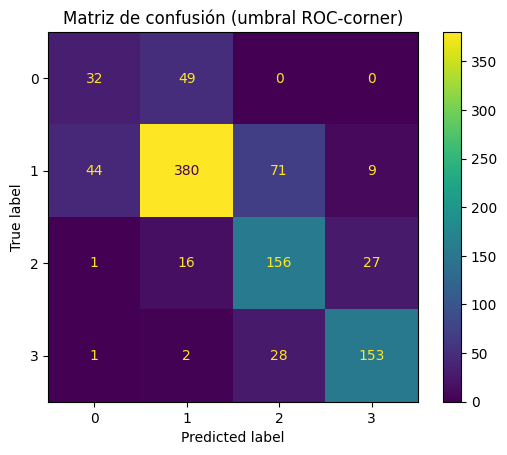

In [47]:
confusion_matrix_mult(best_model1, Y1_train, X_test_significant1, Y1_test, X_val_significant1, Y1_val)

In [48]:
search2 = svc_hiper_search_binary(X_train_significant2, Y2_train)
best_model2 = search2.best_estimator_
print("Mejores hiperparámetros:", search2.best_params_)
print("Mejor f1_macro (CV):", search2.best_score_)

metrics_df, roc_corner = metrics( best_model2, X_train_significant2, X_test_significant2, X_val_significant2, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(1.3292918943162166), 'svc__class_weight': None, 'svc__gamma': np.float64(0.003550621427070771), 'svc__tol': np.float64(0.0021830968390524606)}
Mejor f1_macro (CV): 0.8369367378697198
                     Train      Test       Val
Accuracy (thr*)   0.522076  0.527348  0.517028
Precision (thr*)  0.753247  0.767184  0.755605
Recall (thr*)     0.499462  0.494993  0.484195
ROC AUC           0.593905  0.596098  0.569839

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      1   0.720754  0.399267  0.484195   0.65228


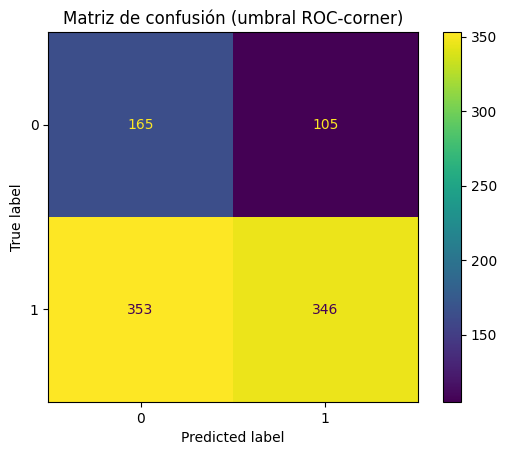

In [49]:
confusion_matrix_binary(best_model2, X_test_significant2, Y2_test, X_val_significant2, Y2_val)

In [50]:
search3 = svc_hiper_search_mult(X_train_significant3, Y3_train)
best_model3 = search3.best_estimator_
print("Mejores hiperparámetros:", search3.best_params_)
print("Mejor f1_macro (CV):", search3.best_score_)

# 7) Evalúa con tu función (recuerda: Test quedó limpio)
metrics_df, roc_corner = metrics( best_model3, X_train_significant3, X_test_significant3, X_val_significant3, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(30.190550386581368), 'svc__cache_size': 200, 'svc__class_weight': None, 'svc__gamma': np.float64(0.0007353119099448623), 'svc__shrinking': True, 'svc__tol': np.float64(0.00021235216307804818)}
Mejor f1_macro (CV): 0.7372308660653987
                     Train      Test       Val
Accuracy (thr*)   0.762200  0.706914  0.749226
Precision (thr*)  0.676267  0.591416  0.635046
Recall (thr*)     0.876125  0.758541  0.795619
ROC AUC           0.945993  0.899799  0.914023

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.774048  0.089286  0.750363  0.265124
1      1   0.125908  0.094092  0.945455  0.108759
2      2   0.229800  0.059887  0.964286  0.069728
3      3   0.169842  0.216184  0.843972  0.266609


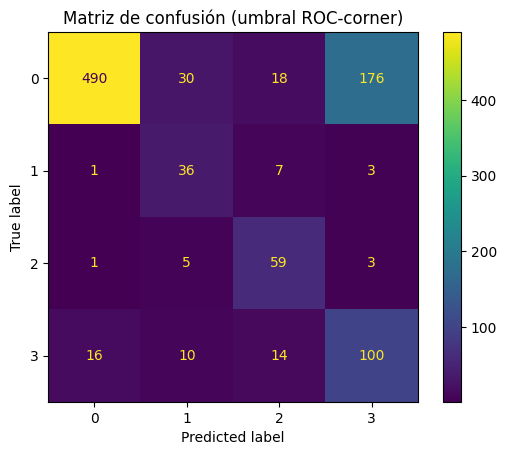

In [51]:
confusion_matrix_mult(best_model3, Y3_train, X_test_significant3, Y3_test, X_val_significant3, Y3_val)

# `Primera aproximación SMOTE para el desbalanceo`

In [52]:
X1_sm, Y1_sm = smote_fit_resample(X, Y1, ratio=1.0, sampler="kmeans", clean="enn", k_neighbors=1, random_state=42, verbose=True)
X1_train_sm, X1_rest_sm, Y1_train_sm, Y1_rest_sm = train_test_split(X1_sm, Y1_sm, test_size=0.6, random_state=42, stratify=Y1_sm)
X1_test_sm, X1_val_sm, Y1_test_sm, Y1_val_sm, = train_test_split(X1_rest_sm, Y1_rest_sm,test_size=0.5, random_state=42, stratify=Y1_rest_sm)

X2_sm, Y2_sm = smote_fit_resample(X, Y2,ratio=1.0, sampler="borderline1", clean="tomek", k_neighbors=1, m_neighbors=5, random_state=42, verbose=True)
X2_train_sm, X2_rest_sm, Y2_train_sm, Y2_rest_sm = train_test_split(X2_sm, Y2_sm, test_size=0.6, random_state=42, stratify=Y2_sm)
X2_test_sm, X2_val_sm, Y2_test_sm, Y2_val_sm, = train_test_split(X2_rest_sm, Y2_rest_sm,test_size=0.5, random_state=42, stratify=Y2_rest_sm)

X3_sm, Y3_sm = smote_fit_resample(X, Y3,ratio=1.0, sampler="kmeans", clean="enn", k_neighbors=1, random_state=42, verbose=True)
X3_train_sm, X3_rest_sm, Y3_train_sm, Y3_rest_sm = train_test_split(X3_sm, Y3_sm, test_size=0.6, random_state=42, stratify=Y3_sm)
X3_test_sm, X3_val_sm, Y3_test_sm, Y3_val_sm, = train_test_split(X3_rest_sm, Y3_rest_sm,test_size=0.5, random_state=42, stratify=Y3_rest_sm)


Distribución original: Counter({np.int64(1): 1678, np.int64(2): 666, np.int64(3): 615, np.int64(0): 270})
sampler=kmeans, clean=enn, k_neighbors=1
Estrategia: {np.int64(3): 1678, np.int64(2): 1678, np.int64(0): 1678}
Distribución SMOTE: Counter({np.int64(1): 1678, np.int64(0): 1539, np.int64(3): 1354, np.int64(2): 1215})
Distribución original: Counter({np.int64(1): 2324, np.int64(0): 905})
sampler=borderline1, clean=tomek, k_neighbors=1
Estrategia: {np.int64(0): 2324}
Distribución SMOTE: Counter({np.int64(0): 2324, np.int64(1): 2237})
Distribución original: Counter({np.int64(0): 2359, np.int64(3): 434, np.int64(2): 259, np.int64(1): 177})
sampler=kmeans, clean=enn, k_neighbors=1
Estrategia: {np.int64(2): 2359, np.int64(3): 2359, np.int64(1): 2359}
Distribución SMOTE: Counter({np.int64(0): 2359, np.int64(1): 2269, np.int64(2): 2262, np.int64(3): 2044})


In [53]:
logreg_smote1 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote1.fit(X1_train_sm, Y1_train_sm)
metrics_df, roc_corner = metrics(logreg_smote1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.892826  0.857719  0.881336
Precision (thr*)  0.893035  0.859439  0.885281
Recall (thr*)     0.895464  0.862177  0.884910
ROC AUC           0.982765  0.973676  0.974433

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.369262  0.063579  0.924242  0.098902
1      1   0.337261  0.094156  0.875000  0.156494
2      2   0.298364  0.061953  0.961538  0.072921
3      3   0.268636  0.024812  0.972906  0.036738


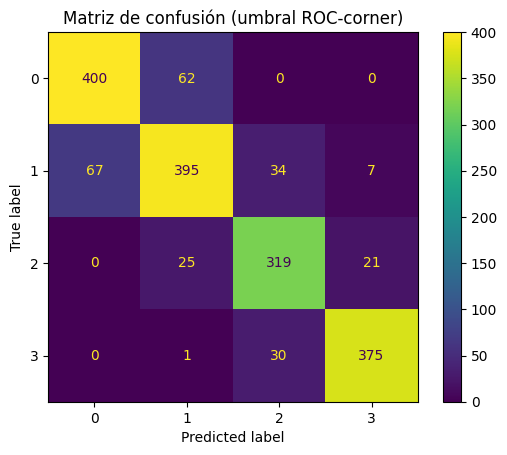

In [54]:
confusion_matrix_mult(logreg_smote1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [55]:
logreg_smote2 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote2.fit(X2_train_sm, Y2_train_sm)
metrics_df, roc_corner = metrics(logreg_smote2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.636513  0.610380  0.613587
Precision (thr*)  0.639759  0.611290  0.611285
Recall (thr*)     0.593296  0.564829  0.581222
ROC AUC           0.680712  0.634850  0.647603

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      1   0.517033  0.355301  0.581222  0.549194


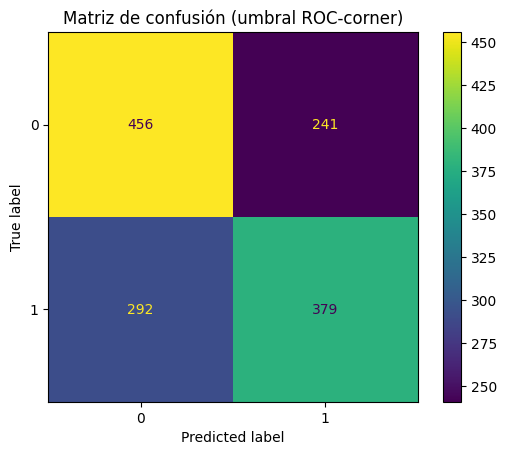

In [56]:
confusion_matrix_binary(logreg_smote2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [57]:
logreg_smote3 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote3.fit(X3_train_sm, Y3_train_sm)
metrics_df, roc_corner = metrics(logreg_smote3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.776099  0.757090  0.766132
Precision (thr*)  0.771749  0.750694  0.762461
Recall (thr*)     0.771770  0.752115  0.762173
ROC AUC           0.938299  0.924984  0.927114

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.248019  0.098834  0.864407  0.167791
1      1   0.314391  0.121500  0.914831  0.148378
2      2   0.267246  0.109890  0.917526  0.137397
3      3   0.337231  0.165377  0.753670  0.296695


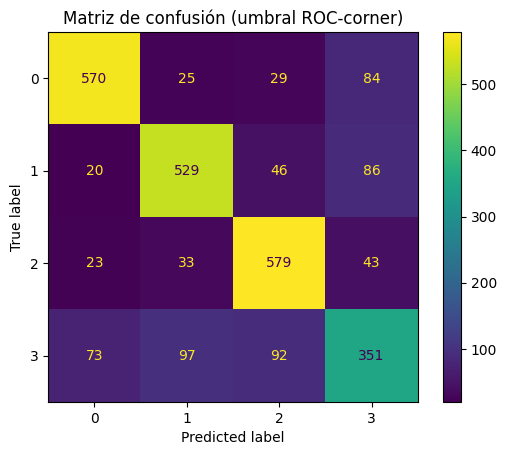

In [58]:
confusion_matrix_mult(logreg_smote3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

In [59]:
search1 = svc_hiper_search_mult(X1_train_sm, Y1_train_sm)
svc_smote1 = search1.best_estimator_
print("Mejores hiperparámetros:", search1.best_params_)
print("Mejor f1_macro (CV):", search1.best_score_)

metrics_df, roc_corner = metrics(svc_smote1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(35.03926475174853), 'svc__cache_size': 1000, 'svc__class_weight': None, 'svc__gamma': np.float64(0.0030377408279046777), 'svc__shrinking': False, 'svc__tol': np.float64(0.002693643916317941)}
Mejor f1_macro (CV): 0.9349614981517368
                     Train      Test       Val
Accuracy (thr*)   0.999136  0.961406  0.955069
Precision (thr*)  0.999221  0.962672  0.956799
Recall (thr*)     0.999221  0.962889  0.956789
ROC AUC           0.999996  0.992588  0.989681

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.551199  0.021193  0.956710  0.048199
1      1   0.202166  0.043019  0.954365  0.062715
2      2   0.096519  0.024781  0.986264  0.028334
3      3   0.202771  0.010526  0.995074  0.011622


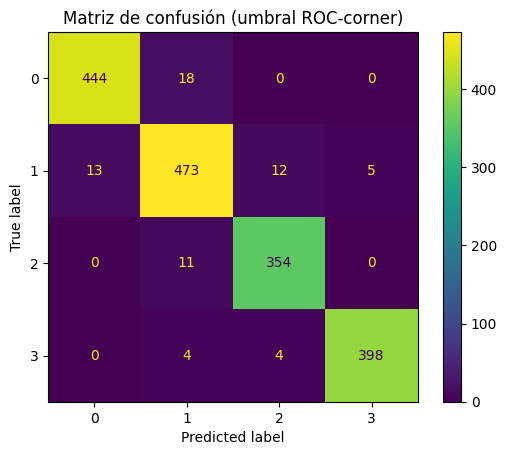

In [60]:
confusion_matrix_mult(svc_smote1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [61]:
search2 = svc_hiper_search_binary(X2_train_sm, Y2_train_sm)
svc_smote2 = search2.best_estimator_
print("Mejores hiperparámetros:", search2.best_params_)
print("Mejor f1_macro (CV):", search2.best_score_)

metrics_df, roc_corner = metrics(svc_smote2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(17.356982090814228), 'svc__class_weight': 'balanced', 'svc__gamma': np.float64(0.17080932213449768), 'svc__tol': np.float64(0.0014548552070164159)}
Mejor f1_macro (CV): 0.7985793886021049
                  Train      Test       Val
Accuracy (thr*)     1.0  0.817982  0.815924
Precision (thr*)    1.0  0.785135  0.791377
Recall (thr*)       1.0  0.865872  0.847988
ROC AUC             1.0  0.877720  0.878327

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold     FPR       TPR  distance
0      1   0.749388  0.2149  0.847988  0.263229


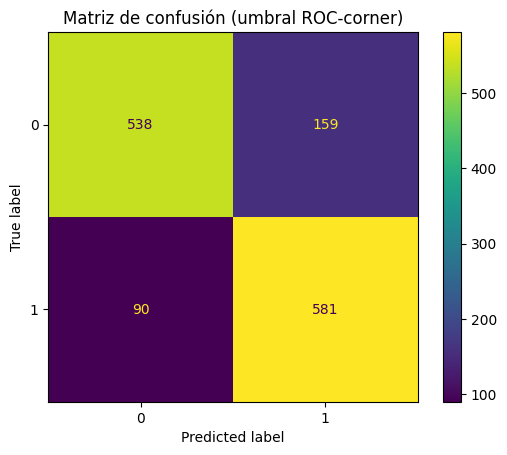

In [62]:
confusion_matrix_binary(svc_smote2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [63]:
search3 = svc_hiper_search_mult(X3_train_sm, Y3_train_sm)
svc_smote3 = search3.best_estimator_
print("Mejores hiperparámetros:", search3.best_params_)
print("Mejor f1_macro (CV):", search3.best_score_)

metrics_df, roc_corner = metrics(svc_smote3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Mejores hiperparámetros: {'svc__C': np.float64(1.6949768237884724), 'svc__cache_size': 1000, 'svc__class_weight': None, 'svc__gamma': np.float64(0.019780827689353773), 'svc__shrinking': True, 'svc__tol': np.float64(0.0006358358856676254)}
Mejor f1_macro (CV): 0.9774403294285054
                  Train      Test       Val
Accuracy (thr*)     1.0  0.985821  0.980977
Precision (thr*)    1.0  0.985852  0.981359
Recall (thr*)       1.0  0.985888  0.981289
ROC AUC             1.0  0.999246  0.999349

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.060931  0.021287  0.994350  0.022024
1      1   0.415849  0.003000  0.986784  0.013552
2      2   0.116863  0.006993  0.995582  0.008272
3      3   0.434097  0.007253  0.993475  0.009757


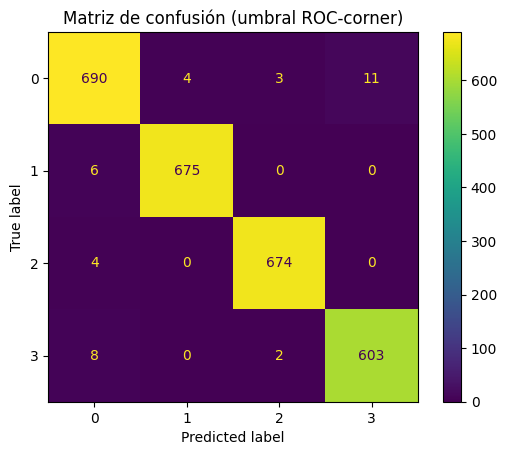

In [64]:
confusion_matrix_mult(svc_smote3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

# `Cluster`

In [65]:
model_htA1 = train_cluster_then_classify(X1_train_sm, Y1_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote1#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.757563  0.733871  0.731567
Precision (thr*)  0.759737  0.734408  0.732201
Recall (thr*)     0.758004  0.735131  0.730902
ROC AUC           0.935239  0.925747  0.928484

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.187861  0.161695  0.941558  0.171933
1      1   0.283293  0.198864  0.807540  0.276745
2      2   0.350151  0.112974  0.898352  0.151972
3      3   0.302341  0.145865  0.918719  0.166982


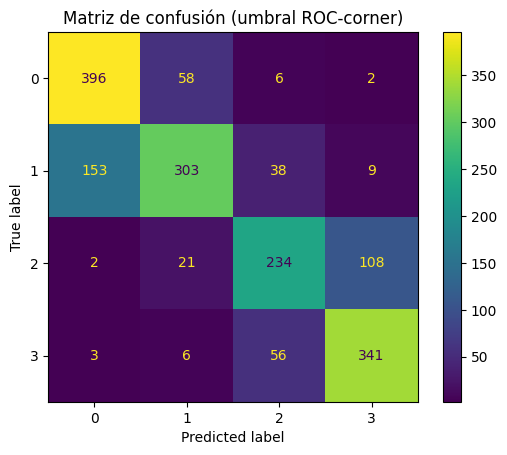

In [66]:
confusion_matrix_mult(model_htA1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [67]:
model_htA2 = train_cluster_then_classify(X2_train_sm, Y2_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote2#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.576206  0.571637  0.573411
Precision (thr*)  0.576441  0.568218  0.568289
Recall (thr*)     0.513966  0.527571  0.539493
ROC AUC           0.586904  0.587518  0.569647

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      1   0.492151  0.393983  0.539493  0.606044


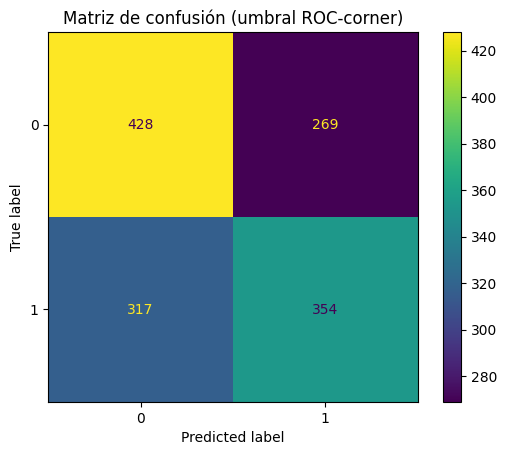

In [68]:
confusion_matrix_binary(model_htA2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [69]:
model_htA3 = train_cluster_then_classify(X3_train_sm, Y3_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote3#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.812762  0.810821  0.802313
Precision (thr*)  0.811440  0.809970  0.801824
Recall (thr*)     0.807301  0.805434  0.796739
ROC AUC           0.931446  0.922695  0.927809

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.241717  0.102382  0.896893  0.145304
1      1   0.210415  0.105500  0.923642  0.130234
2      2   0.446580  0.096903  0.902798  0.137253
3      3   0.347764  0.115571  0.750408  0.275051


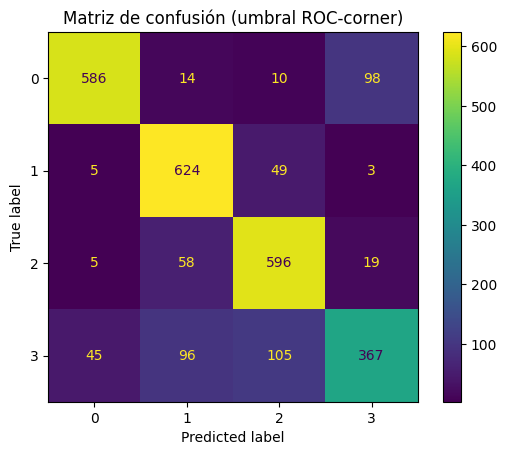

In [70]:
confusion_matrix_mult(model_htA3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

In [71]:
model_specs = [
    {"name":"Regresión Logística IMC", "model":logreg_model,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"Regresión Logística Significante IMC", "model":logreg_model_est,
     "X_train":X_train_significant1, "X_test":X_test_significant1, "X_val":X_val_significant1,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"SVC IMC", "model":best_model1,
     "X_train":X_train_significant1, "X_test":X_test_significant1, "X_val":X_val_significant1,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"Regresión Logística Significante SMOTE IMC", "model":logreg_smote1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"SVC SMOTE IMC", "model":svc_smote1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"Cluster Classifier IMC", "model":model_htA1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"Regresión Logística Glucemia", "model":logreg_model2,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"Regresión Logística Significante Glucemia", "model":logreg_model2_est,
     "X_train":X_train_significant2, "X_test":X_test_significant2, "X_val":X_val_significant2,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"SVC Glucemia", "model":best_model2,
     "X_train":X_train_significant2, "X_test":X_test_significant2, "X_val":X_val_significant2,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"Regresión Logística Significante SMOTE Glucemia", "model":logreg_smote2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"SVC SMOTE Glucemia", "model":svc_smote2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"Cluster Classifier Glucemia", "model":model_htA2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"Regresión Logística HTA", "model":logreg_model3,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"Regresión Logística Significante HTA", "model":logreg_model3_est,
     "X_train":X_train_significant3, "X_test":X_test_significant3, "X_val":X_val_significant3,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"SVC HTA", "model":best_model3,
     "X_train":X_train_significant3, "X_test":X_test_significant3, "X_val":X_val_significant3,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"Regresión Logística Significante SMOTE HTA", "model":logreg_smote3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

    {"name":"SVC SMOTE HTA", "model":svc_smote3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

    {"name":"Cluster Classifier HTA", "model":model_htA3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

]

panel_df, test_df, roc_table, styled_panel, styled_test = compare_models_multi_data(
    model_specs,
    metrics_fn=metrics,         # tu metrics que devuelve (metrics_df, roc_corner_df)
    prefer_split="Test",
    float_fmt="{:.3f}"
)

# Vista “panel” completa (todas las métricas, todos los splits)
display(styled_panel.set_caption("Comparativa de modelos (todas las métricas / splits)"))

# Vista rápida del split Test
if styled_test is not None:
    display(styled_test.set_caption("Split: Test"))

# Tabla de umbrales/ROC-corner (si metrics los generó)
if roc_table is not None:
    display(
        roc_table.style
        .format({"threshold":"{:.3f}", "FPR":"{:.3f}", "TPR":"{:.3f}", "distance":"{:.3f}"})
        .set_caption("Umbrales por clase (ROC corner) por modelo")
    )

,Regresión Logística IMC,Regresión Logística Significante IMC,SVC IMC,Regresión Logística Significante SMOTE IMC,SVC SMOTE IMC,Cluster Classifier IMC,Regresión Logística Glucemia,Regresión Logística Significante Glucemia,SVC Glucemia,Regresión Logística Significante SMOTE Glucemia,SVC SMOTE Glucemia,Cluster Classifier Glucemia,Regresión Logística HTA,Regresión Logística Significante HTA,SVC HTA,Regresión Logística Significante SMOTE HTA,SVC SMOTE HTA,Cluster Classifier HTA
ROC AUC,0.914,0.914,0.911,0.974,0.993,0.926,0.597,0.578,0.596,0.635,0.878,0.588,0.799,0.795,0.900,0.925,0.999,0.923
Precision (thr*),0.676,0.676,0.670,0.859,0.963,0.734,0.768,0.767,0.767,0.611,0.785,0.568,0.450,0.434,0.591,0.751,0.986,0.810
Recall (thr*),0.712,0.702,0.690,0.862,0.963,0.735,0.565,0.545,0.495,0.565,0.866,0.528,0.558,0.549,0.759,0.752,0.986,0.805
Accuracy (thr*),0.738,0.744,0.744,0.858,0.961,0.734,0.563,0.552,0.527,0.610,0.818,0.572,0.621,0.618,0.707,0.757,0.986,0.811


,model,class,threshold,FPR,TPR,distance
0,Regresión Logística IMC,0,0.093,0.211,0.864,0.251
1,Regresión Logística IMC,1,0.592,0.215,0.845,0.265
2,Regresión Logística IMC,2,0.204,0.234,0.890,0.259
3,Regresión Logística IMC,3,0.238,0.071,0.951,0.086
4,Regresión Logística Significante IMC,0,0.094,0.212,0.852,0.258
5,Regresión Logística Significante IMC,1,0.581,0.223,0.861,0.263
6,Regresión Logística Significante IMC,2,0.284,0.168,0.880,0.206
7,Regresión Logística Significante IMC,3,0.256,0.079,0.962,0.088
8,SVC IMC,0,0.139,0.163,0.852,0.220
9,SVC IMC,1,0.601,0.200,0.853,0.248


Probar el desbalanceo primero
Después hacer la división de datos

In [72]:
model_specs = [
    {"name":"Regresión Logística IMC", "model":logreg_model,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"SVC SMOTE IMC", "model":svc_smote1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    
]

panel_df, test_df, roc_table, styled_panel, styled_test = compare_models_multi_data(
    model_specs,
    metrics_fn=metrics,         # tu metrics que devuelve (metrics_df, roc_corner_df)
    prefer_split="Test",
    float_fmt="{:.3f}"
)

# Vista “panel” completa (todas las métricas, todos los splits)
display(styled_panel.set_caption("Comparativa de modelos (todas las métricas / splits)"))

In [73]:
model_specs = [
    {"name":"Regresión Logística Glucemia", "model":logreg_model2,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"SVC SMOTE Glucemia", "model":svc_smote2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

]

panel_df, test_df, roc_table, styled_panel, styled_test = compare_models_multi_data(
    model_specs,
    metrics_fn=metrics,         # tu metrics que devuelve (metrics_df, roc_corner_df)
    prefer_split="Test",
    float_fmt="{:.3f}"
)

# Vista “panel” completa (todas las métricas, todos los splits)
display(styled_panel.set_caption("Comparativa de modelos (todas las métricas / splits)"))

In [74]:
model_specs = [
    {"name":"Regresión Logística HTA", "model":logreg_model3,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"SVC SMOTE HTA", "model":svc_smote3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

]

panel_df, test_df, roc_table, styled_panel, styled_test = compare_models_multi_data(
    model_specs,
    metrics_fn=metrics,         # tu metrics que devuelve (metrics_df, roc_corner_df)
    prefer_split="Test",
    float_fmt="{:.3f}"
)

# Vista “panel” completa (todas las métricas, todos los splits)
display(styled_panel.set_caption("Comparativa de modelos (todas las métricas / splits)"))